# 01 — Convex Optimization and Constrained Finite-Time Optimal Control

## From geometry and KKT conditions to an optimal-control problem a solver can actually solve

Optimization is the computational engine behind predictive control. Before discussing
receding-horizon feedback, invariant terminal sets, Learning MPC, or autonomous racing,
we need to understand **what optimization problem is being solved**, why some formulations
are tractable, what the solver is certifying, and how a dynamical system becomes a finite-dimensional
optimization problem.

This notebook develops that layer carefully.

The central chain is

$$
\boxed{
\text{geometry}
\rightarrow
\text{convexity}
\rightarrow
\text{optimality}
\rightarrow
\text{duality/KKT}
\rightarrow
\text{QP}
\rightarrow
\text{CFTOC}
}
$$

and then, for linear dynamics with quadratic costs,

$$
\boxed{
\text{CFTOC}
\rightarrow
\text{sparse QP}
\quad\text{or}\quad
\text{condensed QP}.
}
$$


## Scope of this notebook

This chapter is intentionally narrower than the full repository.

| Topic | Here? | Where it is developed |
|---|---:|---|
| Convex sets and convex functions | **Yes** | 01 |
| LPs, QPs, KKT conditions, duality | **Yes** | 01 |
| Finite-horizon optimal control / CFTOC | **Yes** | 01 |
| Sparse and condensed optimal-control formulations | **Yes** | 01 |
| Nonlinear finite-horizon control example | **Yes** | 01 |
| Polytope reachability and invariant-set algorithms | No | 02 |
| Recursive feasibility and MPC stability proofs | No | 03 |
| Vehicle–bike mixed-integer collision avoidance | No | 04 |
| Learning MPC safe sets and learned terminal costs | No | 05 |
| Minimum-time racing in Frenet coordinates | No | 06 |
| Local data-driven prediction models | No | 07 |
| Dynamic programming and reinforcement learning | No | 08 |

> **Important:** a CFTOC problem is a finite-horizon optimization problem.  
> **MPC is the feedback strategy obtained by repeatedly solving such a problem, applying the
> first action, measuring the new state, and solving again.**
>
> We stop before the receding-horizon stability theory; that belongs to Notebook 03.


## Learning objectives

After working through this notebook, you should be able to:

1. write an optimization problem in standard constrained form;
2. recognize common convex sets used in control;
3. test convexity of a quadratic objective using its Hessian;
4. explain why convexity changes the meaning of a local optimum;
5. derive the Lagrangian, dual function, and KKT conditions;
6. interpret Lagrange multipliers as **constraint shadow prices**;
7. distinguish LP, convex QP, nonconvex QP, NLP, and mixed-integer formulations;
8. formulate a constrained finite-time optimal-control problem;
9. distinguish the **prediction model** from the plant/test model;
10. derive the stacked prediction equation

$$
X=S_xx_0+S_uU;
$$

11. derive the condensed QP Hessian and linear term;
12. translate state, input, terminal, and input-rate constraints into matrix inequalities;
13. construct equivalent sparse and condensed QPs and verify that they agree;
14. understand why a nonlinear unicycle CFTOC becomes a nonconvex nonlinear program.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import block_diag
from scipy.optimize import minimize, minimize_scalar, NonlinearConstraint, Bounds

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.qp import solve_qp
from advanced_mpc_lmpc.linear import prediction_matrices, rollout

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — Optimization as geometry](#part-1)** — I.1 The generic constrained optimization problem · I.2 Convex sets · I.3 Convex functions · I.4 Convex optimization problems · I.5 LP, convex QP, nonconvex QP, and mixed-integer problems
- **[Part II — Optimality, duality, and KKT conditions](#part-2)** — II.1 Unconstrained optimality · II.2 The Lagrangian · II.3 The dual function and weak duality · II.4 Karush–Kuhn–Tucker conditions · II.5 A QP we can solve analytically · II.6 Lagrange multipliers as sensitivity information · II.7 Dual of a strictly convex QP · II.8 Hard and soft constraints · II.9 Solver classes and what they mean
- **[Part III — Constrained finite-time optimal control](#part-3)** — III.1 Plant dynamics versus prediction dynamics · III.2 The CFTOC problem · III.3 Direct transcription: keep states and inputs as decision variables · III.4 Condensing: eliminate all predicted states · III.5 Condensing a quadratic cost · III.6 Condensing constraints
- **[Part IV — A complete linear-quadratic CFTOC](#part-4)** — IV.1 The same CFTOC in sparse form · IV.2 Sparse versus condensed formulations
- **[Part V — A nonlinear CFTOC: the unicycle](#part-5)** — V.1 Model · V.2 Nonlinear terminal-pose problem · V.3 What changed when the dynamics became nonlinear?
- **[Part VI — Numerical and modeling habits](#part-6)** — VI.1 Never report only “the solver converged” · VI.2 Scaling · VI.3 Modeling decisions are optimization decisions
- **[Part VII — Check your understanding](#part-7)**
- **[Part VIII — Exercises](#part-8)**
- **[Part IX — Where the repository goes next](#part-9)**
- **[Part X — Scope and further reading](#part-10)**


<a id="part-1"></a>
# Part I — Optimization as geometry

## I.1 The generic constrained optimization problem

A broad class of optimization problems can be written as

$$
\begin{aligned}
\min_{z\in\mathbb R^n}\quad & f(z)\\
\text{subject to}\quad
& g_i(z)\le 0,\qquad i=1,\ldots,m,\\
& h_j(z)=0,\qquad j=1,\ldots,p.
\end{aligned}
$$

The vector $z$ contains the **decision variables**.

The set

$$
\mathcal F
=
\left\{
z:
g_i(z)\le 0,\;
h_j(z)=0
\right\}
$$

is the **feasible set**.

The optimizer is

$$
z^\star\in\arg\min_{z\in\mathcal F}f(z),
$$

and the optimal value is

$$
f^\star=f(z^\star).
$$

This distinction matters:

- the **optimizer** is a point (or a set of points);
- the **optimal value** is a scalar;
- a point can be feasible without being optimal;
- a problem can be infeasible, unbounded, or have multiple minimizers.

In control, $z$ will often contain an entire predicted state/input trajectory.


## I.2 Convex sets

A set $\mathcal C\subseteq\mathbb R^n$ is convex if, for every $x,y\in\mathcal C$
and every $\theta\in[0,1]$,

$$
\theta x+(1-\theta)y\in\mathcal C.
$$

Geometrically: the full line segment joining any two feasible points remains feasible.

Several sets appear constantly in optimization and MPC.

### Affine set

$$
\mathcal A=\{z:Az=b\}.
$$

### Hyperplane

$$
\mathcal H=\{z:a^\top z=b\}.
$$

### Half-space

$$
\mathcal H_-=\{z:a^\top z\le b\}.
$$

### Polyhedron

An intersection of finitely many half-spaces:

$$
\mathcal P=\{z:Gz\le h\}.
$$

A bounded polyhedron is a **polytope**.

State constraints, actuator limits, rate limits, and many terminal constraints in linear MPC
are naturally represented by these objects.


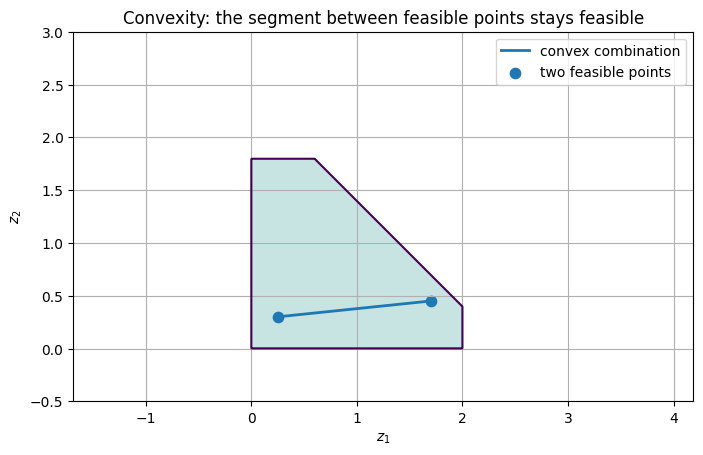

In [2]:
# A 2-D convex feasible set defined by linear inequalities.
x1 = np.linspace(-0.5, 3.0, 500)
x2 = np.linspace(-0.5, 3.0, 500)
X1, X2 = np.meshgrid(x1, x2)

mask = (
    (X1 >= 0.0)
    & (X2 >= 0.0)
    & (X1 + X2 <= 2.4)
    & (X1 <= 2.0)
    & (X2 <= 1.8)
)

plt.figure()
plt.contourf(X1, X2, mask.astype(float), levels=[0.5, 1.5], alpha=0.25)
plt.contour(X1, X2, mask.astype(float), levels=[0.5], linewidths=1.5)

a = np.array([0.25, 0.30])
b = np.array([1.70, 0.45])
theta = np.linspace(0.0, 1.0, 100)
segment = theta[:, None] * a + (1.0 - theta[:, None]) * b

plt.plot(segment[:, 0], segment[:, 1], linewidth=2, label="convex combination")
plt.scatter([a[0], b[0]], [a[1], b[1]], s=55, label="two feasible points")
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("Convexity: the segment between feasible points stays feasible")
plt.axis("equal")
plt.legend()
plt.show()


### Why convexity matters geometrically

If $\mathcal F$ is convex, there are no disconnected feasible “islands.”
This does **not** by itself guarantee that optimization is easy—the objective matters too—but
it gives the feasible geometry needed by convex optimization theory.

Useful closure properties:

- the intersection of convex sets is convex;
- affine images of convex sets are convex;
- inverse images of convex sets under affine maps are convex;
- a Cartesian product of convex sets is convex.

These facts explain why stacking many linear state/input constraints over a horizon still yields
a convex feasible set.


## I.3 Convex functions

A function $f:\mathcal C\to\mathbb R$ on a convex domain is convex if

$$
f(\theta x+(1-\theta)y)
\le
\theta f(x)+(1-\theta)f(y)
$$

for all $x,y\in\mathcal C$ and $\theta\in[0,1]$.

For a differentiable convex function,

$$
f(y)\ge f(x)+\nabla f(x)^\top(y-x).
$$

So every tangent hyperplane is a **global lower bound**.

For a twice continuously differentiable function,

$$
\nabla^2 f(z)\succeq0
$$

everywhere on a convex domain is sufficient for convexity.

For the quadratic function

$$
f(z)=\frac12 z^\top Pz+q^\top z+r,
$$

the Hessian is simply

$$
\nabla^2 f=P.
$$

Therefore

$$
\boxed{
f\text{ is convex}
\iff
P\succeq0.
}
$$

If $P\succ0$, the function is strictly convex.


Convex quadratic eigenvalues:    [1.15341 3.34659]
Nonconvex quadratic eigenvalues: [-0.6  1. ]


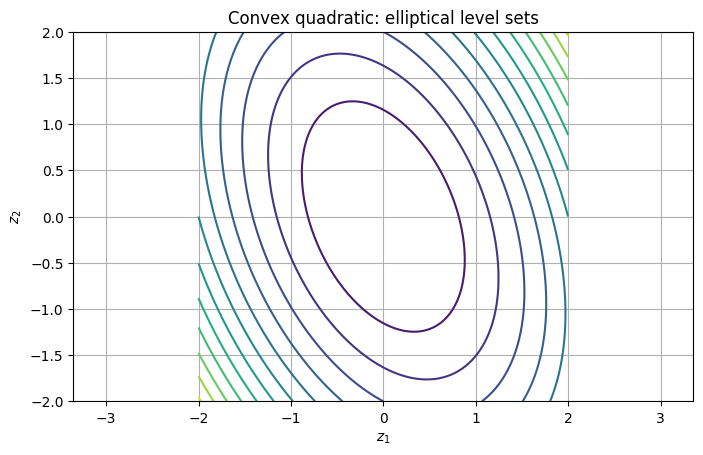

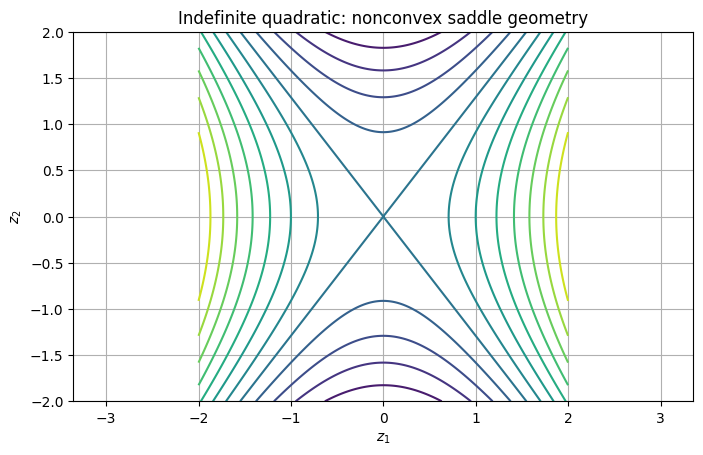

In [3]:
# Compare a convex quadratic with an indefinite (nonconvex) quadratic.

P_convex = np.array([[3.0, 0.8],
                     [0.8, 1.5]])

P_nonconvex = np.array([[1.0, 0.0],
                        [0.0, -0.6]])

print("Convex quadratic eigenvalues:   ", np.linalg.eigvalsh(P_convex))
print("Nonconvex quadratic eigenvalues:", np.linalg.eigvalsh(P_nonconvex))

g = np.linspace(-2.0, 2.0, 250)
Z1, Z2 = np.meshgrid(g, g)

F1 = 0.5 * (
    P_convex[0, 0] * Z1**2
    + 2 * P_convex[0, 1] * Z1 * Z2
    + P_convex[1, 1] * Z2**2
)

F2 = 0.5 * (
    P_nonconvex[0, 0] * Z1**2
    + 2 * P_nonconvex[0, 1] * Z1 * Z2
    + P_nonconvex[1, 1] * Z2**2
)

plt.figure()
plt.contour(Z1, Z2, F1, levels=12)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("Convex quadratic: elliptical level sets")
plt.axis("equal")
plt.show()

plt.figure()
plt.contour(Z1, Z2, F2, levels=12)
plt.xlabel(r"$z_1$")
plt.ylabel(r"$z_2$")
plt.title("Indefinite quadratic: nonconvex saddle geometry")
plt.axis("equal")
plt.show()


## I.4 Convex optimization problems

A standard differentiable convex optimization problem has the form

$$
\begin{aligned}
\min_z\quad & f_0(z)\\
\text{s.t.}\quad
& f_i(z)\le0,\qquad i=1,\ldots,m,\\
& Az=b,
\end{aligned}
$$

where

- $f_0$ is convex;
- every inequality function $f_i$ is convex;
- equality constraints are affine.

The key consequence is

$$
\boxed{
\text{every local optimum is a global optimum.}
}
$$

If, in addition, the objective is strictly convex on the feasible set, there is at most one
optimizer.

This is the main reason convexity is so valuable in control: it changes optimization from
“search for a good local solution” into “solve a problem with global optimality structure.”


## I.5 LP, convex QP, nonconvex QP, and mixed-integer problems

### Linear program (LP)

$$
\begin{aligned}
\min_z\quad & c^\top z\\
\text{s.t.}\quad & Gz\le h,\\
& Az=b.
\end{aligned}
$$

### Convex quadratic program (QP)

$$
\begin{aligned}
\min_z\quad
&\frac12z^\top Pz+q^\top z\\
\text{s.t.}\quad
&Gz\le h,\\
&Az=b,
\end{aligned}
$$

with

$$
P\succeq0.
$$

A linear optimal-control problem with quadratic costs and polyhedral constraints is typically a QP.

### Nonconvex QP

The same quadratic form becomes nonconvex if $P$ is indefinite.

### Mixed-integer optimization

If some decision variables satisfy conditions such as

$$
s_i\in\{0,1\},
$$

the feasible set becomes discrete/nonconvex. This is the mechanism used later to encode
logical alternatives such as “pass before an obstacle” versus “remain behind it.”

We postpone the vehicle–bike mixed-integer example to Notebook 04.


<a id="part-2"></a>
# Part II — Optimality, duality, and KKT conditions

## II.1 Unconstrained optimality

For

$$
\min_z f(z),
$$

a differentiable local optimum $z^\star$ in the interior of the domain must satisfy

$$
\nabla f(z^\star)=0.
$$

For a twice differentiable function, a local minimum also requires the Hessian to be
positive semidefinite at that point:

$$
\nabla^2 f(z^\star)\succeq0.
$$

For a **convex differentiable** function, the condition

$$
\nabla f(z^\star)=0
$$

is not merely local—it is sufficient for global optimality.


## II.2 The Lagrangian

For

$$
\begin{aligned}
\min_z\quad &f(z)\\
\text{s.t.}\quad &g(z)\le0,\\
&h(z)=0,
\end{aligned}
$$

introduce multipliers

$$
\lambda\ge0,\qquad \nu\in\mathbb R^p
$$

and define

$$
\boxed{
L(z,\lambda,\nu)
=
f(z)+\lambda^\top g(z)+\nu^\top h(z).
}
$$

The multipliers quantify how strongly the active constraints influence the optimum.

This interpretation becomes very useful in control:

- a multiplier on steering saturation tells us how costly that limit is;
- a multiplier on a state boundary tells us how strongly it shapes the optimal trajectory;
- a zero multiplier usually indicates that the corresponding inequality is locally inactive.


## II.3 The dual function and weak duality

The Lagrange dual function is

$$
d(\lambda,\nu)
=
\inf_z L(z,\lambda,\nu).
$$

For any dual-feasible $\lambda\ge0$,

$$
d(\lambda,\nu)\le f^\star.
$$

This is **weak duality**: every dual-feasible point provides a lower bound on the primal optimum.

The dual problem is

$$
\max_{\lambda\ge0,\nu}d(\lambda,\nu).
$$

If its optimum equals the primal optimum,

$$
d^\star=f^\star,
$$

we have **strong duality**.

For convex problems, a standard sufficient constraint qualification is **Slater's condition**:
roughly, there exists a feasible point that satisfies every non-affine inequality strictly
and lies in the relative interior of the domain.

When strong duality holds, primal/dual solutions provide an optimality certificate through the
primal-dual gap.


## II.4 Karush–Kuhn–Tucker conditions

Under the usual differentiability assumptions, and in particular for convex problems satisfying
an appropriate constraint qualification such as Slater's condition, an optimum satisfies:

### 1. Stationarity

$$
\nabla f(z^\star)
+
\sum_{i=1}^m\lambda_i^\star\nabla g_i(z^\star)
+
\sum_{j=1}^p\nu_j^\star\nabla h_j(z^\star)
=0.
$$

### 2. Primal feasibility

$$
g_i(z^\star)\le0,\qquad h_j(z^\star)=0.
$$

### 3. Dual feasibility

$$
\lambda_i^\star\ge0.
$$

### 4. Complementary slackness

$$
\boxed{
\lambda_i^\star g_i(z^\star)=0.
}
$$

This last relation has an immediate interpretation:

- if $g_i(z^\star)<0$, then $\lambda_i^\star=0$;
- if $\lambda_i^\star>0$, then the constraint must be active.

For differentiable convex problems with strong duality, the KKT conditions are also sufficient
for global optimality.


## II.5 A QP we can solve analytically

Consider

$$
\min_z \|z-c\|_2^2,
\qquad
c=
\begin{bmatrix}
1.2\\0.8
\end{bmatrix},
$$

subject to

$$
z_1+z_2\le1.
$$

The unconstrained minimizer is $z=c$, but

$$
1.2+0.8=2>1,
$$

so the constraint is active at the constrained optimum.

Dropping the constant $c^\top c$, the objective is

$$
\frac12z^\top Pz+q^\top z,
$$

with

$$
P=2I,
\qquad
q=-2c.
$$

Let

$$
a=
\begin{bmatrix}1\\1\end{bmatrix}.
$$

The KKT stationarity condition is

$$
2z-2c+\lambda a=0,
$$

so

$$
z=c-\frac{\lambda}{2}a.
$$

Since the inequality is active,

$$
a^\top z=1,
$$

hence

$$
\lambda^\star=1
$$

and

$$
\boxed{
z^\star=
\begin{bmatrix}
0.7\\0.3
\end{bmatrix}.
}
$$


In [4]:
c = np.array([1.2, 0.8])
P_qp = 2.0 * np.eye(2)
q_qp = -2.0 * c

A_qp = np.array([[1.0, 1.0]])
b_qp = np.array([1.0])

qp = solve_qp(P_qp, q_qp, A_ub=A_qp, b_ub=b_qp)

z_star = qp.x
lambda_star = 1.0  # obtained analytically above

print("Solver success:", qp.success)
print("z*             :", z_star)
print("expected       :", np.array([0.7, 0.3]))
print("constraint     :", A_qp @ z_star, "<=", b_qp)
print("lambda*        :", lambda_star)


Solver success: True
z*             : [0.7 0.3]
expected       : [0.7 0.3]
constraint     : [1.] <= [1.]
lambda*        : 1.0


In [5]:
# Verify the four KKT ingredients numerically.

grad_f = P_qp @ z_star + q_qp
g = float((A_qp @ z_star - b_qp)[0])
stationarity = grad_f + A_qp.T.ravel() * lambda_star
complementarity = lambda_star * g

print("gradient of objective :", grad_f)
print("stationarity residual :", stationarity)
print("primal residual g(z*) :", g)
print("dual feasibility      :", lambda_star >= 0.0)
print("complementarity       :", complementarity)


gradient of objective : [-1. -1.]
stationarity residual : [0. 0.]
primal residual g(z*) : 1.1102230246251565e-15
dual feasibility      : True
complementarity       : 1.1102230246251565e-15


## II.6 Lagrange multipliers as sensitivity information

Now replace the bound $1$ with a parameter $b$:

$$
z_1+z_2\le b.
$$

When this constraint remains active, the sensitivity relation is

$$
\frac{d f^\star}{db}=-\lambda^\star.
$$

So the multiplier is a **shadow price**:

> how much would the optimal cost improve if the constraint were relaxed slightly?

For the present QP,

$$
\lambda^\star=2-b
$$

while the constraint is active.


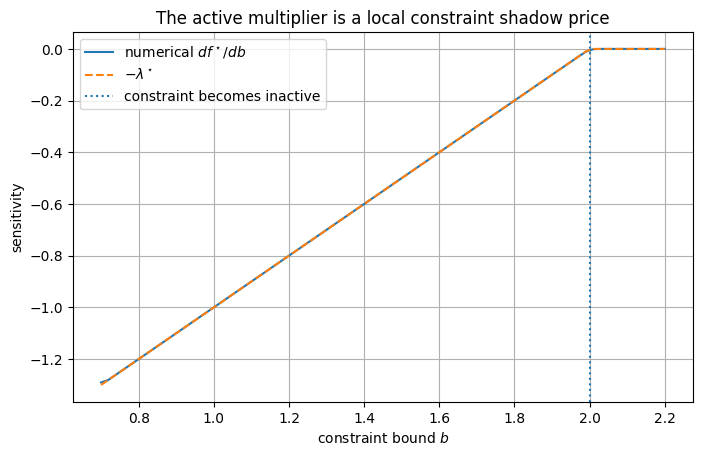

In [6]:
bs = np.linspace(0.7, 2.2, 80)
values = []
lambdas = []

for b in bs:
    res = solve_qp(P_qp, q_qp, A_ub=A_qp, b_ub=np.array([b]))
    values.append(res.objective)
    lambdas.append(max(2.0 - b, 0.0))

values = np.asarray(values)
lambdas = np.asarray(lambdas)
dv_db = np.gradient(values, bs)

plt.figure()
plt.plot(bs, dv_db, label=r"numerical $d f^\star/db$")
plt.plot(bs, -lambdas, "--", label=r"$-\lambda^\star$")
plt.axvline(2.0, linestyle=":", label="constraint becomes inactive")
plt.xlabel(r"constraint bound $b$")
plt.ylabel("sensitivity")
plt.title("The active multiplier is a local constraint shadow price")
plt.legend()
plt.show()


## II.7 Dual of a strictly convex QP

Consider

$$
\begin{aligned}
\min_z\quad
&\frac12z^\top Pz+q^\top z\\
\text{s.t.}\quad
&Az\le b,
\end{aligned}
$$

with $P\succ0$.

The Lagrangian is

$$
L(z,\lambda)
=
\frac12z^\top Pz+q^\top z+\lambda^\top(Az-b),
\qquad
\lambda\ge0.
$$

Minimization with respect to $z$ gives

$$
Pz+q+A^\top\lambda=0,
$$

hence

$$
z(\lambda)
=
-P^{-1}(q+A^\top\lambda).
$$

Substituting back,

$$
\boxed{
d(\lambda)
=
-\frac12
(q+A^\top\lambda)^\top
P^{-1}
(q+A^\top\lambda)
-b^\top\lambda.
}
$$

The dual problem is

$$
\max_{\lambda\ge0}d(\lambda).
$$

This gives a second way to see the same multiplier and allows us to inspect the primal-dual gap.


In [7]:
P_inv = np.linalg.inv(P_qp)

def dual_value(lam):
    lam = float(lam)
    y = q_qp + A_qp.T.ravel() * lam
    return -0.5 * y @ P_inv @ y - b_qp[0] * lam

dual_res = minimize_scalar(
    lambda lam: -dual_value(lam),
    bounds=(0.0, 10.0),
    method="bounded",
)

lam_dual = dual_res.x
d_star = dual_value(lam_dual)
p_star = qp.objective

print("primal optimum       :", p_star)
print("dual optimum         :", d_star)
print("primal-dual gap      :", p_star - d_star)
print("dual multiplier      :", lam_dual)
print("analytical multiplier:", lambda_star)


primal optimum       : -1.5800000000000012
dual optimum         : -1.58
primal-dual gap      : -1.1102230246251565e-15
dual multiplier      : 1.0000000000000004
analytical multiplier: 1.0


## II.8 Hard and soft constraints

A **hard constraint**

$$
a^\top z\le b
$$

must always be satisfied.

Sometimes feasibility is more important than exact enforcement. Introduce a slack variable

$$
\epsilon\ge0
$$

and write

$$
a^\top z\le b+\epsilon.
$$

Then penalize the violation:

$$
J_{\text{soft}}
=
J+\rho\epsilon
$$

or

$$
J_{\text{soft}}
=
J+\rho\epsilon^2.
$$

This produces a **soft constraint**.

The distinction is an engineering decision:

- physical actuator limits are usually hard;
- collision constraints should normally be treated as hard safety requirements;
- comfort or tracking envelopes may sometimes be softened;
- a slack variable can prevent numerical infeasibility, but it does **not** make a safety
violation acceptable.

Always document which constraints are hard and which are soft.


## II.9 Solver classes and what they mean

The mathematical structure determines the solver class.

| Structure | Typical class |
|---|---|
| linear objective + linear constraints | LP |
| convex quadratic objective + linear constraints | convex QP |
| nonlinear smooth objective/constraints | NLP |
| integer/binary decisions | MILP / MIQP / MINLP |
| indefinite quadratic objective | nonconvex QP |

This repository deliberately uses SciPy-based routines so that the examples run without an
external solver runtime.

For large real-time MPC problems, dedicated solvers are often more appropriate, for example
OSQP, qpOASES, HPIPM, FORCES, GUROBI, MOSEK, or other problem-specific tools.

The solver name is less important than understanding the structure of the problem it is given.


<a id="part-3"></a>
# Part III — Constrained finite-time optimal control

## III.1 Plant dynamics versus prediction dynamics

Let the physical/test system evolve as

$$
x[t+1]
=
f_{\mathrm{test}}(x[t],u[t]).
$$

Inside the optimizer we use a prediction model

$$
x_{k+1}
=
f(x_k,u_k).
$$

The two functions need not be identical.

This notation distinction is important:

- $t$ denotes real closed-loop time;
- $k$ denotes prediction time inside the optimization;
- $f_{\mathrm{test}}$ represents the system being controlled;
- $f$ is the model used to predict its future.

If $f=f_{\mathrm{test}}$, we have a nominal perfect-model simulation.
If they differ, prediction errors and robustness become relevant.

We will later study more sophisticated handling of uncertainty; here we first formulate the
nominal optimization problem correctly.


## III.2 The CFTOC problem

Given the measured/current state

$$
x_0=\bar x,
$$

consider

$$
\begin{aligned}
\min_{u_0,\ldots,u_{N-1}}
\quad&
p(x_N)
+
\sum_{k=0}^{N-1}q(x_k,u_k)\\
\text{subject to}\quad
&
x_{k+1}=f(x_k,u_k),
\\
&
x_k\in\mathcal X,
\qquad
u_k\in\mathcal U,
\\
&
x_N\in\mathcal X_T,
\\
&
x_0=\bar x.
\end{aligned}
$$

where

- $q(x,u)$ is the **stage cost**;
- $p(x_N)$ is the **terminal cost**;
- $\mathcal X$ is the admissible state set;
- $\mathcal U$ is the admissible input set;
- $\mathcal X_T$ is a terminal target/set.

This is a **constrained finite-time optimal-control problem (CFTOC)**.

### CFTOC is not yet MPC

A one-shot CFTOC gives an open-loop optimal sequence

$$
U^\star=
\{u_0^\star,\ldots,u_{N-1}^\star\}.
$$

MPC will later solve a related problem repeatedly in feedback.


## III.3 Direct transcription: keep states and inputs as decision variables

For a horizon $N$, define

$$
X=
\begin{bmatrix}
x_1\\x_2\\\vdots\\x_N
\end{bmatrix},
\qquad
U=
\begin{bmatrix}
u_0\\u_1\\\vdots\\u_{N-1}
\end{bmatrix}.
$$

A **sparse/direct** formulation uses

$$
z=
\begin{bmatrix}
X\\U
\end{bmatrix}
$$

as the optimization variable.

The dynamics are equality constraints.

For the LTI system

$$
x_{k+1}=Ax_k+Bu_k,
$$

they become

$$
\begin{aligned}
x_1-Bu_0 &= Ax_0,\\
x_2-Ax_1-Bu_1 &=0,\\
&\vdots\\
x_N-Ax_{N-1}-Bu_{N-1}&=0.
\end{aligned}
$$

This formulation contains many variables, but its matrices are highly sparse.

That sparsity is valuable for large horizons and specialized optimal-control solvers.


## III.4 Condensing: eliminate all predicted states

Because the linear dynamics can be propagated analytically,

$$
x_1=Ax_0+Bu_0,
$$

$$
x_2
=
A^2x_0+ABu_0+Bu_1,
$$

$$
x_3
=
A^3x_0+A^2Bu_0+ABu_1+Bu_2.
$$

Stacking the predictions gives

$$
\boxed{
X=S_xx_0+S_uU,
}
$$

where

$$
S_x=
\begin{bmatrix}
A\\
A^2\\
\vdots\\
A^N
\end{bmatrix}
$$

and

$$
S_u=
\begin{bmatrix}
B & 0 & \cdots & 0\\
AB & B & \cdots & 0\\
A^2B & AB & \ddots & \vdots\\
\vdots & \vdots & \ddots & B
\end{bmatrix}.
$$

Now the state sequence is no longer an independent decision variable.

The optimizer can work only with $U$.


In [8]:
# Build and verify prediction matrices on a double integrator.

Ts = 0.5

A = np.array([
    [1.0, Ts],
    [0.0, 1.0],
])

B = np.array([
    [0.5 * Ts**2],
    [Ts],
])

N = 6
Sx, Su = prediction_matrices(A, B, N)

x0 = np.array([-2.0, 0.25])
U_test = np.array([[0.4], [0.2], [0.0], [-0.2], [-0.3], [0.1]])

X_condensed = (Sx @ x0 + Su @ U_test.ravel()).reshape(N, 2)
X_rollout = rollout(A, B, x0, U_test)[1:]

print("max |stacked prediction - direct rollout| =",
      np.max(np.abs(X_condensed - X_rollout)))
print("\nPredicted states:")
print(X_condensed)


max |stacked prediction - direct rollout| = 2.220446049250313e-16

Predicted states:
[[-1.825   0.45  ]
 [-1.575   0.55  ]
 [-1.3     0.55  ]
 [-1.05    0.45  ]
 [-0.8625  0.3   ]
 [-0.7     0.35  ]]


## III.5 Condensing a quadratic cost

Consider the quadratic finite-horizon cost

$$
J
=
\sum_{k=1}^{N-1}x_k^\top Qx_k
+
x_N^\top Px_N
+
\sum_{k=0}^{N-1}u_k^\top Ru_k.
$$

Define

$$
\bar Q
=
\operatorname{blkdiag}(Q,\ldots,Q,P),
$$

and

$$
\bar R
=
\operatorname{blkdiag}(R,\ldots,R).
$$

Then

$$
J
=
X^\top\bar QX+U^\top\bar RU.
$$

Substitute

$$
X=S_xx_0+S_uU.
$$

Expanding,

$$
\begin{aligned}
J
={}&
U^\top
\left(
S_u^\top\bar QS_u+\bar R
\right)U
\\
&+
2x_0^\top S_x^\top\bar QS_uU
\\
&+
x_0^\top S_x^\top\bar QS_xx_0.
\end{aligned}
$$

The last term is constant with respect to $U$.

Using the standard QP convention

$$
\frac12U^\top HU+f^\top U,
$$

we obtain

$$
\boxed{
H
=
2\left(
S_u^\top\bar QS_u+\bar R
\right)
}
$$

and

$$
\boxed{
f(x_0)
=
2S_u^\top\bar QS_xx_0.
}
$$

Notice that the current state $x_0$ enters the QP as a **parameter**.


## III.6 Condensing constraints

Suppose the state set is polyhedral:

$$
F_xx_k\le g_x.
$$

Stacking gives

$$
\bar F_xX\le\bar g_x.
$$

Using

$$
X=S_xx_0+S_uU,
$$

we obtain

$$
\boxed{
\bar F_xS_uU
\le
\bar g_x-\bar F_xS_xx_0.
}
$$

Input constraints

$$
F_uu_k\le g_u
$$

can be stacked directly as linear inequalities in $U$.

A terminal equality

$$
x_N=x_f
$$

becomes

$$
\boxed{
S_{u,N}U
=
x_f-S_{x,N}x_0.
}
$$

### Input-rate constraints

For

$$
\Delta u_k=u_k-u_{k-1},
$$

we can build a block difference matrix $D$ such that

$$
\Delta U=DU+d(u_{-1}).
$$

Therefore

$$
-\Delta u_{\max}
\le
DU+d(u_{-1})
\le
\Delta u_{\max}
$$

is again a pair of linear inequalities.


In [9]:
def difference_matrix(N, m):
    # D such that [u0, u1-u0, ..., uN-1-uN-2] = D U.
    D = np.zeros((N * m, N * m))
    I = np.eye(m)

    D[:m, :m] = I
    for k in range(1, N):
        D[k*m:(k+1)*m, (k-1)*m:k*m] = -I
        D[k*m:(k+1)*m, k*m:(k+1)*m] = I

    return D

D_demo = difference_matrix(5, 1)
print(D_demo)


[[ 1.  0.  0.  0.  0.]
 [-1.  1.  0.  0.  0.]
 [ 0. -1.  1.  0.  0.]
 [ 0.  0. -1.  1.  0.]
 [ 0.  0.  0. -1.  1.]]


<a id="part-4"></a>
# Part IV — A complete linear-quadratic CFTOC

We now solve one finite-horizon regulation problem end to end.

The plant model is the sampled double integrator

$$
x_{k+1}=Ax_k+Bu_k,
$$

with

$$
x=
\begin{bmatrix}
p\\v
\end{bmatrix},
$$

where $p$ is position and $v$ is velocity.

We impose:

$$
|p_k|\le5,
\qquad
|v_k|\le2,
$$

$$
|u_k|\le0.8,
$$

and

$$
|\Delta u_k|\le0.5.
$$

The terminal state must satisfy

$$
x_N=0.
$$

This is a convex QP.


In [10]:
Ts = 0.5

A = np.array([
    [1.0, Ts],
    [0.0, 1.0],
])

B = np.array([
    [0.5 * Ts**2],
    [Ts],
])

n, m = B.shape
N = 12
x0 = np.array([-4.0, 0.0])

Q = np.diag([1.0, 0.2])
P = np.diag([8.0, 1.0])
R = np.array([[0.10]])

Sx, Su = prediction_matrices(A, B, N)

Qbar = block_diag(*([Q] * (N - 1) + [P]))
Rbar = block_diag(*([R] * N))

H = 2.0 * (Su.T @ Qbar @ Su + Rbar)
f = 2.0 * Su.T @ Qbar @ Sx @ x0

print("Smallest eigenvalue of H:", np.min(np.linalg.eigvalsh(H)))


Smallest eigenvalue of H: 0.22561029149792766


In [11]:
# State constraints: |position| <= 5, |velocity| <= 2.

Fx = np.array([
    [ 1.0,  0.0],
    [-1.0,  0.0],
    [ 0.0,  1.0],
    [ 0.0, -1.0],
])

gx = np.array([5.0, 5.0, 2.0, 2.0])

Fbar = block_diag(*([Fx] * N))
gbar = np.tile(gx, N)

A_state = Fbar @ Su
b_state = gbar - Fbar @ Sx @ x0

# Input-rate constraints.
D = difference_matrix(N, m)
u_previous = np.array([0.0])

d_offset = np.zeros(N * m)
d_offset[:m] = -u_previous

du_max = 0.5

A_rate = np.vstack([D, -D])
b_rate = np.hstack([
    du_max * np.ones(N * m) - d_offset,
    du_max * np.ones(N * m) + d_offset,
])

A_ub = np.vstack([A_state, A_rate])
b_ub = np.hstack([b_state, b_rate])

# Terminal equality x_N = 0.
Sx_N = Sx[-n:, :]
Su_N = Su[-n:, :]

A_eq = Su_N
b_eq = -Sx_N @ x0

result_condensed = solve_qp(
    H,
    f,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    lb=-0.8 * np.ones(N * m),
    ub= 0.8 * np.ones(N * m),
)

qp_constant = float(x0 @ Sx.T @ Qbar @ Sx @ x0)
true_cost_condensed = result_condensed.objective + qp_constant

print("solver success                  :", result_condensed.success)
print("max constraint violation        :", result_condensed.max_violation)
print("condensed objective (no constant):", result_condensed.objective)
print("dropped constant                :", qp_constant)
print("physical finite-horizon cost    :", true_cost_condensed)


solver success                  : True
max constraint violation        : 2.6201263381153694e-13
condensed objective (no constant): -248.90720110161092
dropped constant                : 304.0
physical finite-horizon cost    : 55.09279889838908


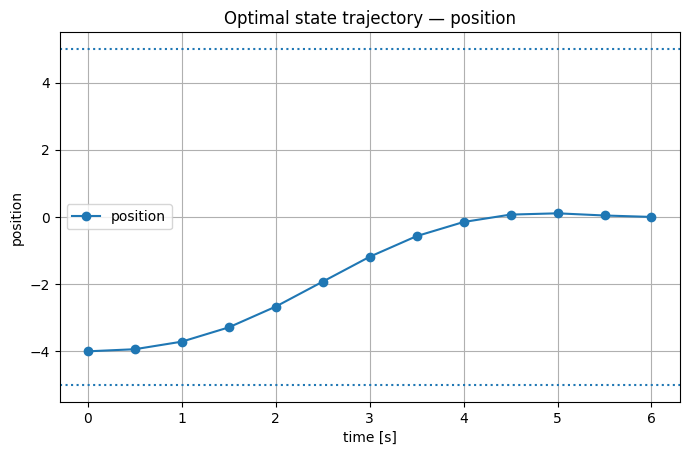

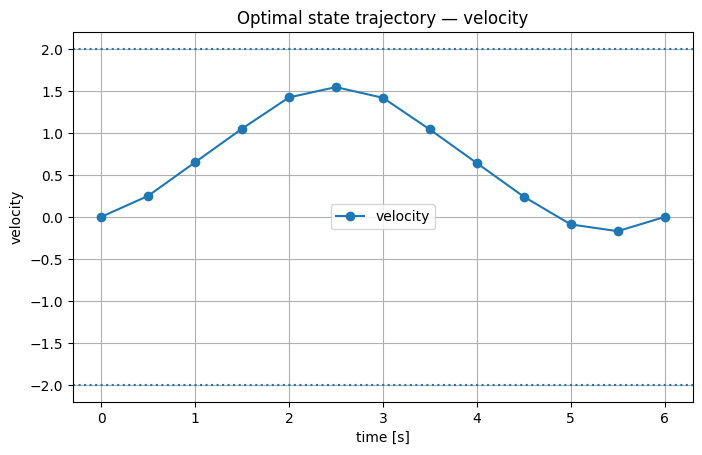

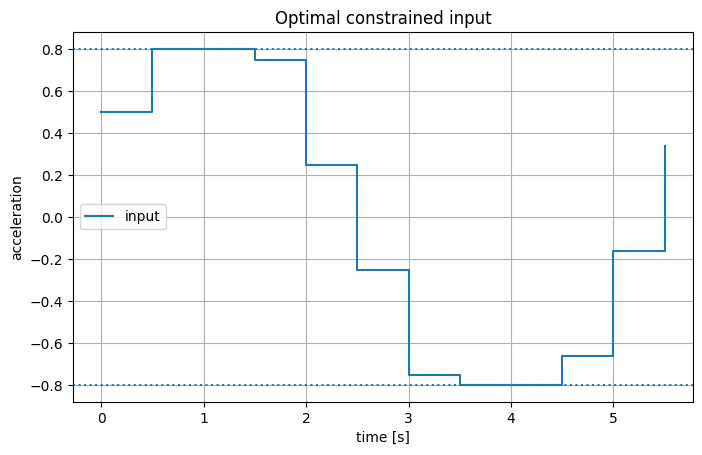

terminal state: [-0. -0.]
maximum |u|  : 0.8
maximum |Δu| : 0.500000000000262


In [12]:
U_star = result_condensed.x.reshape(N, m)
X_star = (Sx @ x0 + Su @ result_condensed.x).reshape(N, n)
trajectory = np.vstack([x0, X_star])

t_x = Ts * np.arange(N + 1)
t_u = Ts * np.arange(N)

plt.figure()
plt.plot(t_x, trajectory[:, 0], marker="o", label="position")
plt.axhline(5.0, linestyle=":")
plt.axhline(-5.0, linestyle=":")
plt.xlabel("time [s]")
plt.ylabel("position")
plt.title("Optimal state trajectory — position")
plt.legend()
plt.show()

plt.figure()
plt.plot(t_x, trajectory[:, 1], marker="o", label="velocity")
plt.axhline(2.0, linestyle=":")
plt.axhline(-2.0, linestyle=":")
plt.xlabel("time [s]")
plt.ylabel("velocity")
plt.title("Optimal state trajectory — velocity")
plt.legend()
plt.show()

plt.figure()
plt.step(t_u, U_star[:, 0], where="post", label="input")
plt.axhline(0.8, linestyle=":")
plt.axhline(-0.8, linestyle=":")
plt.xlabel("time [s]")
plt.ylabel("acceleration")
plt.title("Optimal constrained input")
plt.legend()
plt.show()

print("terminal state:", X_star[-1])
print("maximum |u|  :", np.max(np.abs(U_star)))
print("maximum |Δu| :", np.max(np.abs(np.diff(np.r_[u_previous, U_star[:, 0]]))))


## IV.1 The same CFTOC in sparse form

The condensed formulation eliminated $X$.

Now we solve the **same optimization problem** with the sparse decision vector

$$
z=
\begin{bmatrix}
X\\U
\end{bmatrix}.
$$

The cost matrix becomes block diagonal:

$$
H_{\mathrm{sparse}}
=
2
\begin{bmatrix}
\bar Q & 0\\
0 & \bar R
\end{bmatrix}.
$$

The dynamics reappear as equality constraints.

Mathematically, the sparse and condensed problems are equivalent.
Computationally, they expose different structures to the solver.


In [13]:
nz = N * n + N * m

H_sparse = block_diag(2.0 * Qbar, 2.0 * Rbar)
f_sparse = np.zeros(nz)

# Dynamics equalities.
Aeq_dyn = np.zeros((N * n, nz))
beq_dyn = np.zeros(N * n)

for k in range(N):
    row = slice(k*n, (k+1)*n)

    x_next_col = slice(k*n, (k+1)*n)
    Aeq_dyn[row, x_next_col] = np.eye(n)

    u_col = slice(N*n + k*m, N*n + (k+1)*m)
    Aeq_dyn[row, u_col] = -B

    if k == 0:
        beq_dyn[row] = A @ x0
    else:
        x_prev_col = slice((k-1)*n, k*n)
        Aeq_dyn[row, x_prev_col] = -A

# Terminal equality x_N = 0.
Aeq_terminal = np.zeros((n, nz))
Aeq_terminal[:, (N-1)*n:N*n] = np.eye(n)

A_eq_sparse = np.vstack([Aeq_dyn, Aeq_terminal])
b_eq_sparse = np.hstack([beq_dyn, np.zeros(n)])

# State and rate inequalities.
A_state_sparse = np.hstack([
    Fbar,
    np.zeros((Fbar.shape[0], N*m)),
])

A_rate_sparse = np.hstack([
    np.zeros((A_rate.shape[0], N*n)),
    A_rate,
])

A_ub_sparse = np.vstack([A_state_sparse, A_rate_sparse])
b_ub_sparse = np.hstack([gbar, b_rate])

lb_sparse = np.hstack([
    -np.inf * np.ones(N*n),
    -0.8 * np.ones(N*m),
])

ub_sparse = np.hstack([
     np.inf * np.ones(N*n),
     0.8 * np.ones(N*m),
])

z0_sparse = np.hstack([X_star.reshape(-1), result_condensed.x])

result_sparse = solve_qp(
    H_sparse,
    f_sparse,
    A_ub=A_ub_sparse,
    b_ub=b_ub_sparse,
    A_eq=A_eq_sparse,
    b_eq=b_eq_sparse,
    lb=lb_sparse,
    ub=ub_sparse,
    x0=z0_sparse,
)

U_sparse = result_sparse.x[N*n:].reshape(N, m)
X_sparse = result_sparse.x[:N*n].reshape(N, n)

print("sparse solver success:", result_sparse.success)
print("max |U_sparse - U_condensed|:",
      np.max(np.abs(U_sparse - U_star)))
print("max |X_sparse - X_condensed|:",
      np.max(np.abs(X_sparse - X_star)))
print("sparse physical cost           :", result_sparse.objective)
print("condensed physical cost        :", true_cost_condensed)


sparse solver success: True
max |U_sparse - U_condensed|: 0.0
max |X_sparse - X_condensed|: 0.0
sparse physical cost           : 55.09279889838899
condensed physical cost        : 55.09279889838908


## IV.2 Sparse versus condensed formulations

They solve the same finite-horizon control problem, but they expose different numerical structures.

### Condensed formulation

Decision variable:

$$
U\in\mathbb R^{Nm}.
$$

Advantages:

- fewer decision variables;
- elegant derivation;
- useful for small/medium dense QPs;
- ideal for understanding how $x_0$ parameterizes the optimization.

Disadvantages:

- elimination can destroy sparsity;
- the condensed Hessian is often dense.

### Sparse formulation

Decision variable:

$$
(X,U)\in\mathbb R^{Nn+Nm}.
$$

Advantages:

- dynamics remain sparse equality constraints;
- sparse linear algebra scales well;
- natural for large systems, nonlinear transcription, and structure-exploiting solvers.

Disadvantages:

- more explicit variables and constraints.

There is no universal winner. The better representation depends on problem size, horizon,
solver technology, and real-time requirements.


<a id="part-5"></a>
# Part V — A nonlinear CFTOC: the unicycle

## V.1 Model

Consider

$$
\dot x=v\cos\theta,
$$

$$
\dot y=v\sin\theta,
$$

$$
\dot\theta=\omega.
$$

The state is

$$
z=
\begin{bmatrix}
x\\y\\\theta
\end{bmatrix},
$$

and the input is

$$
u=
\begin{bmatrix}
v\\\omega
\end{bmatrix}.
$$

With forward Euler discretization,

$$
x_{k+1}
=
x_k+T_sv_k\cos\theta_k,
$$

$$
y_{k+1}
=
y_k+T_sv_k\sin\theta_k,
$$

$$
\theta_{k+1}
=
\theta_k+T_s\omega_k.
$$

Unlike the linear double integrator, the prediction map contains sine and cosine terms.
The resulting finite-horizon optimization is therefore a **nonlinear program** and is generally
nonconvex.


## V.2 Nonlinear terminal-pose problem

We ask the unicycle to move from

$$
z_0=
\begin{bmatrix}
0\\0\\0
\end{bmatrix}
$$

to

$$
z_f=
\begin{bmatrix}
2\\1\\0
\end{bmatrix}
$$

while satisfying

$$
|v_k|\le1,
\qquad
|\omega_k|\le1,
$$

and smooth input-rate bounds.

The cost penalizes control effort and changes in the control:

$$
J
=
\alpha\sum_{k=0}^{N-1}\|u_k\|_2^2
+
\beta\sum_{k=1}^{N-1}\|u_k-u_{k-1}\|_2^2.
$$

The terminal pose is imposed as a nonlinear equality constraint.

This example is deliberately small: its purpose is to show how CFTOC extends beyond QPs.


In [14]:
Ts_u = 0.2
N_u = 30

z0 = np.array([0.0, 0.0, 0.0])
zf = np.array([2.0, 1.0, 0.0])

def rollout_unicycle(Uvec):
    U = np.asarray(Uvec).reshape(N_u, 2)
    z = z0.copy()
    states = [z.copy()]

    for v, omega in U:
        z = z + Ts_u * np.array([
            v * np.cos(z[2]),
            v * np.sin(z[2]),
            omega,
        ])
        states.append(z.copy())

    return np.asarray(states)

def unicycle_cost(Uvec):
    U = np.asarray(Uvec).reshape(N_u, 2)
    dU = np.diff(U, axis=0)

    effort = 0.05 * np.sum(U**2)
    smoothness = 0.10 * np.sum(dU**2)
    return effort + smoothness

def terminal_residual(Uvec):
    return rollout_unicycle(Uvec)[-1] - zf

terminal_constraint = NonlinearConstraint(
    terminal_residual,
    lb=np.zeros(3),
    ub=np.zeros(3),
)

def rate_map(Uvec):
    U = np.asarray(Uvec).reshape(N_u, 2)
    return np.diff(U, axis=0).reshape(-1)

rate_constraint = NonlinearConstraint(
    rate_map,
    lb=-0.20 * np.ones(2 * (N_u - 1)),
    ub= 0.20 * np.ones(2 * (N_u - 1)),
)

input_bounds = Bounds(
    np.tile([-1.0, -1.0], N_u),
    np.tile([ 1.0,  1.0], N_u),
)

# Initial guess: move forward, turn, then unwind the heading.
U0 = np.zeros((N_u, 2))
U0[:, 0] = np.sqrt(5.0) / (N_u * Ts_u)
U0[:10, 1] =  0.25
U0[20:, 1] = -0.25

unicycle_result = minimize(
    unicycle_cost,
    U0.reshape(-1),
    method="SLSQP",
    bounds=input_bounds,
    constraints=[terminal_constraint, rate_constraint],
    options={
        "ftol": 1e-10,
        "maxiter": 2000,
        "disp": False,
    },
)

print("success :", unicycle_result.success)
print("message :", unicycle_result.message)
print("cost    :", unicycle_result.fun)
print("terminal residual:", terminal_residual(unicycle_result.x))


success :

 True
message : Optimization terminated successfully
cost    : 0.3166970313324845
terminal residual: [-0.  0. -0.]


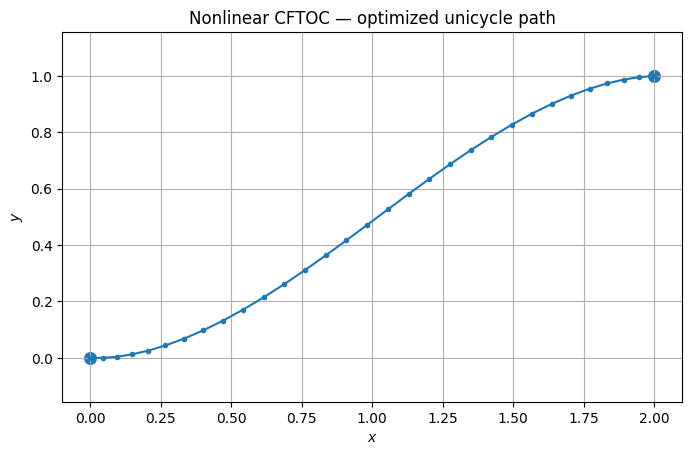

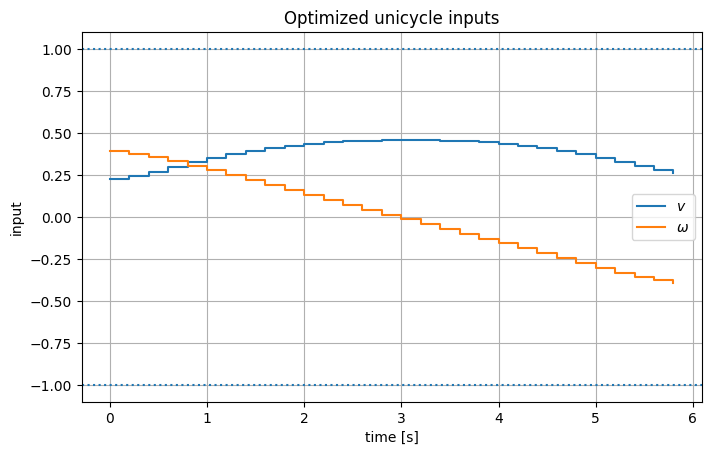

In [15]:
U_uni = unicycle_result.x.reshape(N_u, 2)
Z_uni = rollout_unicycle(unicycle_result.x)

t_uni = Ts_u * np.arange(N_u)

plt.figure()
plt.plot(Z_uni[:, 0], Z_uni[:, 1], marker=".")
plt.scatter([z0[0], zf[0]], [z0[1], zf[1]], s=70)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Nonlinear CFTOC — optimized unicycle path")
plt.axis("equal")
plt.show()

plt.figure()
plt.step(t_uni, U_uni[:, 0], where="post", label=r"$v$")
plt.step(t_uni, U_uni[:, 1], where="post", label=r"$\omega$")
plt.axhline(1.0, linestyle=":")
plt.axhline(-1.0, linestyle=":")
plt.xlabel("time [s]")
plt.ylabel("input")
plt.title("Optimized unicycle inputs")
plt.legend()
plt.show()


## V.3 What changed when the dynamics became nonlinear?

For the linear-quadratic problem:

- dynamics were affine;
- constraints were linear;
- objective was convex quadratic;
- the problem was a convex QP.

For the unicycle:

- the dynamics contain $\sin\theta$ and $\cos\theta$;
- terminal constraints depend nonlinearly on the control sequence;
- the optimization is a nonlinear program;
- the solution returned by a local NLP solver may depend on the initial guess.

Therefore,

$$
\boxed{
\text{solver convergence}
\neq
\text{certificate of global optimality}
}
$$

for a generic nonconvex nonlinear problem.

This distinction is fundamental when moving from linear MPC to nonlinear MPC.


<a id="part-6"></a>
# Part VI — Numerical and modeling habits

## VI.1 Never report only “the solver converged”

For every numerical optimal-control solution, inspect at least:

1. **solver status**;
2. **constraint violation**;
3. **terminal residual**;
4. **active constraints**;
5. **cost value**;
6. **sensitivity to initialization** for nonconvex problems;
7. **conditioning/scaling** of states and inputs;
8. **whether the prediction model matches the simulated/physical plant**.

A beautiful trajectory from an infeasible solution is not a valid control result.


## VI.2 Scaling

Suppose one state is measured in millimeters and another in hundreds of meters per second.
The corresponding optimization matrices can have very different numerical scales.

Poor scaling can produce:

- slow convergence;
- inaccurate KKT residuals;
- unreliable active-set identification;
- unnecessary sensitivity to solver tolerances.

A common remedy is to introduce scaled variables

$$
\tilde x=D_x^{-1}x,
\qquad
\tilde u=D_u^{-1}u,
$$

with diagonal scaling matrices chosen so typical values are of order one.

Weights and constraints must be transformed consistently.


## VI.3 Modeling decisions are optimization decisions

Before writing code, answer:

- What is the decision variable?
- What model predicts the future?
- Which constraints are physical?
- Which constraints are safety-critical?
- Which can be softened?
- Is the terminal condition an equality, a set, or only a cost?
- Is the formulation convex?
- Are there discrete logical decisions?
- Is the model exact or approximate?
- Is the problem solved once, or repeatedly in feedback?

These questions determine the mathematics before they determine the software.


<a id="part-7"></a>
# Part VII — Check your understanding

Try answering each question without looking back.

### Q1. What makes a quadratic program convex?

<details><summary>Answer</summary>

The Hessian of its quadratic objective must be positive semidefinite and the feasible set must
be convex. For the standard QP with affine equality and inequality constraints, this reduces to
$P\succeq0$.

</details>

### Q2. Why are equality constraints required to be affine in the standard convex form?

<details><summary>Answer</summary>

A nonlinear equality $h(z)=0$ generally produces a nonconvex feasible set. An affine equality
preserves convexity.

</details>

### Q3. What does complementary slackness tell you?

<details><summary>Answer</summary>

For each inequality, $\lambda_i^\star g_i(z^\star)=0$. An inactive inequality has zero
multiplier; a positive multiplier implies the constraint is active.

</details>

### Q4. What is the engineering meaning of a Lagrange multiplier?

<details><summary>Answer</summary>

It is a local shadow price: it measures the sensitivity of the optimal value to a small relaxation
of the associated constraint.

</details>

### Q5. What is the difference between weak and strong duality?

<details><summary>Answer</summary>

Weak duality always gives $d^\star\le f^\star$. Strong duality means equality, so the dual
optimum certifies the primal optimum.

</details>

### Q6. What is CFTOC?

<details><summary>Answer</summary>

A constrained finite-time optimal-control problem: optimize a finite input sequence subject to
predicted dynamics, state/input constraints, and possibly terminal constraints.

</details>

### Q7. Why is CFTOC not the same thing as MPC?

<details><summary>Answer</summary>

CFTOC is one finite-horizon optimization. MPC repeatedly solves a finite-horizon problem in
closed loop and applies only the first optimized action before re-solving.

</details>

### Q8. What does condensing do?

<details><summary>Answer</summary>

It eliminates predicted state variables using the dynamics, yielding
$X=S_xx_0+S_uU$, so the optimization can be written only in terms of the input sequence $U$.

</details>

### Q9. Why can sparse and condensed formulations return the same control?

<details><summary>Answer</summary>

They are algebraically equivalent representations of the same dynamics, cost, and constraints;
the difference is numerical representation, not the underlying optimization problem.

</details>

### Q10. Why is the unicycle problem nonconvex?

<details><summary>Answer</summary>

The state predictions depend nonlinearly on the decision variables through trigonometric terms
such as $\sin\theta$ and $\cos\theta$, so the feasible mapping is nonlinear and does not generally
define a convex optimization problem.

</details>


<a id="part-8"></a>
# Part VIII — Exercises

### Exercise 1 — Convexity of a quadratic

For

$$
P=
\begin{bmatrix}
2 & \alpha\\
\alpha & 1
\end{bmatrix},
$$

find the range of $\alpha$ for which

$$
f(z)=\frac12z^\top Pz
$$

is convex.

---

### Exercise 2 — KKT by hand

Solve

$$
\min_{z_1,z_2}
(z_1-3)^2+(z_2-1)^2
$$

subject to

$$
z_1+z_2\le2.
$$

Derive $z^\star$ and $\lambda^\star$ from the KKT conditions.

---

### Exercise 3 — Prediction matrices

For

$$
x_{k+1}=Ax_k+Bu_k,
$$

write $x_4$ explicitly as a function of $x_0,u_0,u_1,u_2,u_3$.
Then identify the fourth block row of $S_x$ and $S_u$.

---

### Exercise 4 — State-constraint condensation

Starting from

$$
F_xx_k\le g_x,
$$

derive the inequality in $U$ for a stacked horizon.

---

### Exercise 5 — Rate constraints

Construct $D$ for $N=4$ and a scalar input, and verify that

$$
DU+
\begin{bmatrix}
-u_{-1}\\0\\0\\0
\end{bmatrix}
=
\begin{bmatrix}
u_0-u_{-1}\\
u_1-u_0\\
u_2-u_1\\
u_3-u_2
\end{bmatrix}.
$$

---

### Exercise 6 — Sparse versus condensed size

For $n=8$, $m=2$, and $N=30$, compare the number of decision variables in the sparse and
fully condensed formulations.

What computational property may make the larger sparse problem faster anyway?

---

### Exercise 7 — Nonlinear CFTOC

Change the unicycle target pose and initial guess.

Do you always obtain the same local solution?
What does that tell you about nonconvex optimization?


<a id="part-9"></a>
# Part IX — Where the repository goes next

This notebook established the optimization machinery.

The next chapters separate the remaining ideas instead of hiding them inside one giant notebook:

- **02 — Polytopes, reachability, and invariance:** geometry of feasible/safe sets;
- **03 — MPC stability and terminal sets:** recursive feasibility, shifted sequences, Lyapunov arguments;
- **04 — Collision avoidance CFTOC:** logical maneuver choices and mixed-integer structure;
- **05 — Learning MPC:** safe sets and terminal value functions learned from successful repetitions;
- **06 — Racing in Frenet coordinates:** minimum-time control and track geometry;
- **07 — Data-driven local models:** learning local prediction dynamics;
- **08 — Dynamic programming to reinforcement learning:** Bellman recursion, values, policies;
- **09 — Capstone:** synthesis and extensions.

The roadmap in Notebook 00 shows how these chapters fit together.


<a id="part-10"></a>
# Part X — Scope and further reading

**Scope.** This notebook covers the optimization layer that the rest of the series builds on: convex
sets and functions, LP and QP structure, Lagrangian duality and the KKT conditions, solver classes,
hard and soft constraints, the constrained finite-time optimal-control problem, its sparse and
condensed QP forms for linear systems, and a small nonlinear (unicycle) example. It assumes linear
algebra and multivariable calculus. Receding-horizon feedback and its feasibility and stability theory
are developed in Notebook 03.

**Further reading.**

- S. Boyd and L. Vandenberghe, *Convex Optimization*, Cambridge University Press, 2004: convex sets
  and functions, duality, KKT conditions.
- J. Nocedal and S. J. Wright, *Numerical Optimization*, 2nd ed., Springer, 2006: algorithms for
  quadratic and nonlinear programs.
- F. Borrelli, A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*,
  Cambridge University Press, 2017: constrained finite-time optimal control and its QP formulations.
- D. P. Bertsekas, *Dynamic Programming and Optimal Control*, Vol. I, 4th ed., Athena Scientific, 2017.

The repository file `docs/references.md` collects the references for the whole series.
